# Demand Forecasting Modeling

This notebook develops forecasting models for the top-selling product families.

The workflow includes:

- Time series preparation
- Feature engineering
- Baseline forecasting models
- LightGBM forecasting
- Prophet comparison
- Model evaluation

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import lightgbm as lgb

from prophet import Prophet

import joblib

Importing plotly failed. Interactive plots will not work.


In [3]:
df = pd.read_csv("../data/train.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
TOP_FAMILIES = [
    "GROCERY I",
    "BEVERAGES",
    "PRODUCE",
    "CLEANING",
    "DAIRY"
]

In [5]:
family_daily = (
    df
    .groupby(["date", "family"])["sales"]
    .sum()
    .reset_index()
)

family_daily = family_daily[
    family_daily["family"].isin(TOP_FAMILIES)
]

family_daily.head()

,date,family,sales
3,2013-01-01,BEVERAGES,810.0
7,2013-01-01,CLEANING,186.0
8,2013-01-01,DAIRY,143.0
12,2013-01-01,GROCERY I,700.0
30,2013-01-01,PRODUCE,0.0


In [6]:
family_daily.info()

<class 'pandas.DataFrame'>
Index: 8420 entries, 3 to 55569
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    8420 non-null   datetime64[us]
 1   family  8420 non-null   str           
 2   sales   8420 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 263.1 KB


In [7]:
family_daily["family"].value_counts()

family
BEVERAGES    1684
CLEANING     1684
DAIRY        1684
GROCERY I    1684
PRODUCE      1684
Name: count, dtype: int64

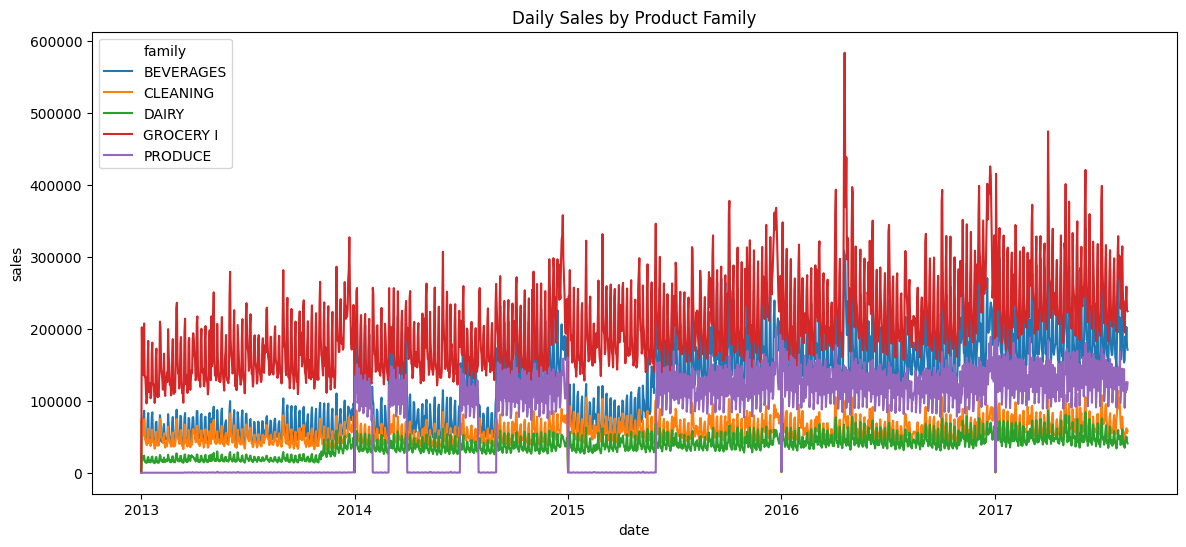

In [8]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=family_daily,
    x="date",
    y="sales",
    hue="family"
)

plt.title("Daily Sales by Product Family")
plt.show()